<a href="https://colab.research.google.com/github/RHG117/Project---NovaRetail/blob/main/Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:

- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales
  
Antes de correlacionar, primero entendemos el “terreno”.



In [9]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Cargar Dataset

In [10]:
# Cargar el dataset y explorar datos
df = pd.read_csv("novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [11]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.



#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados (`int` o `float`), por lo que **no requieren conversión adicional**  

La columna `ingreso_anual` será utiliada como variable objetivo del análisis, ya que representa el ingreso generado por cada cliente al año.

La columna `satisfaccion` se cambiara de float a category.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **requerimos transformación adicional de int a category**.
df['miembro_premium'] = df['miembro_premium'].astype('category')
df['abandono'] = df['abandono'].astype('category')

**miembro_premium**

- 1 = cliente premium
- 0 = cliente estándar

**abandono**

- 1 = cliente que dejó de utilizar la plataforma
- 0 = cliente activo

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

Consideraciones:

- `id_cliente` funciona únicamente como identificador único del usuario, por lo que no será utilizada en el análisis correlacional.
- `tipo_dispositivo` permite analizar posibles diferencias de comportamiento entre usuarios que acceden desde móvil, escritorio o tablet.
- `region` permite explorar diferencias geográficas en el comportamiento de compra.


In [12]:
# Corregir el tipo de dato
# Convertir variables binarias a categóricas
df['miembro_premium'] = df['miembro_premium'].astype('category')
df['abandono'] = df['abandono'].astype('category')

# Convertir satisfacción a ordinal
df['satisfaccion'] = df['satisfaccion'].astype('category')


In [13]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  category
 7   miembro_premium            15000 non-null  category
 8   abandono                   15000 non-null  category
 9   tipo_dispositivo           15000 non-null  object  
 10  region                     15000 non-null  object  
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(3), float64(4), int64(2), object(3)
memory usage: 1.1+ MB


#### Explorar variables numéricas

In [14]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,244.690000


✍️ **Diagnóstico inicial de variables numéricas**:

- `edad` - El hecho de que media y mediana sean casi iguales sugiere una distribución relativamente simétrica.
- `nivel_ingreso` - La media y mediana son prácticamente iguales, lo que indica una distribución bastante equilibrada.
- `visitas_mes` - Los usuarios visitan la plataforma aproximadamente 2–3 veces por semana en promedio.
- `compras-mes` - La mayoría de los usuarios realiza alrededor de una compra por mes.
- `gasto_publicidad_dirigida` - estrategias de segmentación de marketing diferenciadas.
- `ingreso_anual` - El valor máximo es mucho mayor que la media, lo que sugiere la presencia de clientes de alto valor (high-value customers).

#### Explorar variables binarias

In [15]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']
for columna in columnas_binarias:
    print(f"{columna}: {df[columna].nunique()} valores únicos")
    print()
    print(df[columna].describe())
    print()


print("Distribución de miembro_premium:")
print(df['miembro_premium'].value_counts())
print('porcentaje')
print(df['miembro_premium'].value_counts(normalize=True).sort_index() * 100)
print("\nDistribución de abandono:")
print(df['abandono'].value_counts())
print('porcentaje\n', df['abandono'].value_counts(normalize=True).sort_index() * 100)

miembro_premium: 2 valores únicos

count     15000
unique        2
top           0
freq      12911
Name: miembro_premium, dtype: int64

abandono: 2 valores únicos

count     15000
unique        2
top           0
freq      12739
Name: abandono, dtype: int64

Distribución de miembro_premium:
miembro_premium
0    12911
1     2089
Name: count, dtype: int64
porcentaje
miembro_premium
0    86.073333
1    13.926667
Name: proportion, dtype: float64

Distribución de abandono:
abandono
0    12739
1     2261
Name: count, dtype: int64
porcentaje
 abandono
0    84.926667
1    15.073333
Name: proportion, dtype: float64



✍️ **Diagnóstico inicial de variables binarias**:

- `miembro_premium` — Solo 13.9% de los clientes son premium, lo que sugiere que el programa de membresía está dirigido a un segmento relativamente pequeño de la base de usuarios.
- `abandono` — 15% de los clientes han abandonado la plataforma.


#### Explorar variables categóricas

In [16]:
# Verificar el número de valores únicos por variable categórica
df[['id_cliente','tipo_dispositivo','region']].nunique()

,0
id_cliente,15000
tipo_dispositivo,3
region,4


In [17]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo','region']].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
Name: count, dtype: int64

✍️ **Diagnóstico inicial de variables categóricas**:

- `tipo_dispositivo` — móvil es el dispositivo más usado, superando los 2000 usuarios en las cuatro regiones.
- `region` - La region Norte es la que predomina, sin importar que dispositivo se ultilice


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

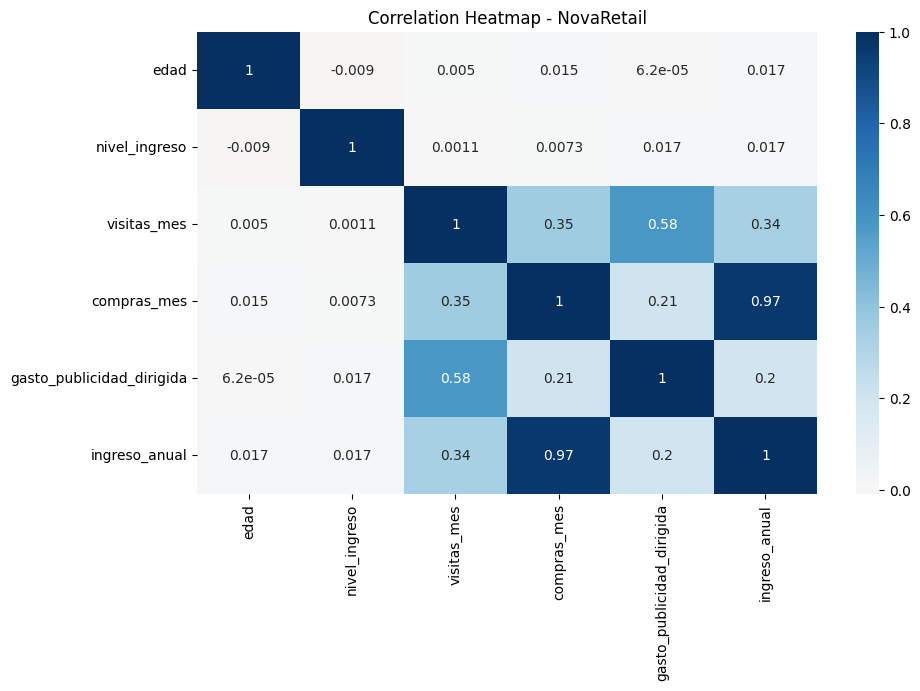

In [18]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[['edad', 'nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','ingreso_anual']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - NovaRetail")
plt.show()

✍️ **Observaciones generales (Heatmap)**:

- Se observa que las variables demográficas como edad y nivel_ingreso muestran correlaciones prácticamente nulas con el resto de las variables del comportamiento del usuario. Esto sugiere que, dentro de este dataset, estas características no influyen significativamente en cómo interactúan los clientes con la plataforma.

Por otro lado, algunas variables relacionadas con la actividad dentro de la plataforma muestran correlaciones moderadas. Por ejemplo:

visitas_mes y compras_mes presentan una correlación positiva moderada (~0.35), lo que sugiere que los usuarios que visitan más la plataforma tienden a realizar más compras.

visitas_mes y gasto_publicidad_dirigida presentan una correlación más notable (~0.58), lo que podría indicar que los usuarios que reciben más publicidad dirigida tienden a interactuar más con la plataforma.

Observaciones respecto a `ingreso_anual`  
- La relación más fuerte se observa con compras_mes, con una correlación de aproximadamente 0.97, lo que indica una asociación extremadamente alta y positiva. Sin embargo esto puede ser que estas columnas estan relacionadas entre si, como si una de ellas estuviera calculada en base a la otra. Lo que compran en el mes son los ingresos anuales por eso la correlación tan alta.

- También se observa una correlación positiva moderada con visitas_mes (~0.34). Esto indica que los usuarios que visitan la plataforma con mayor frecuencia tienden a generar más ingresos.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

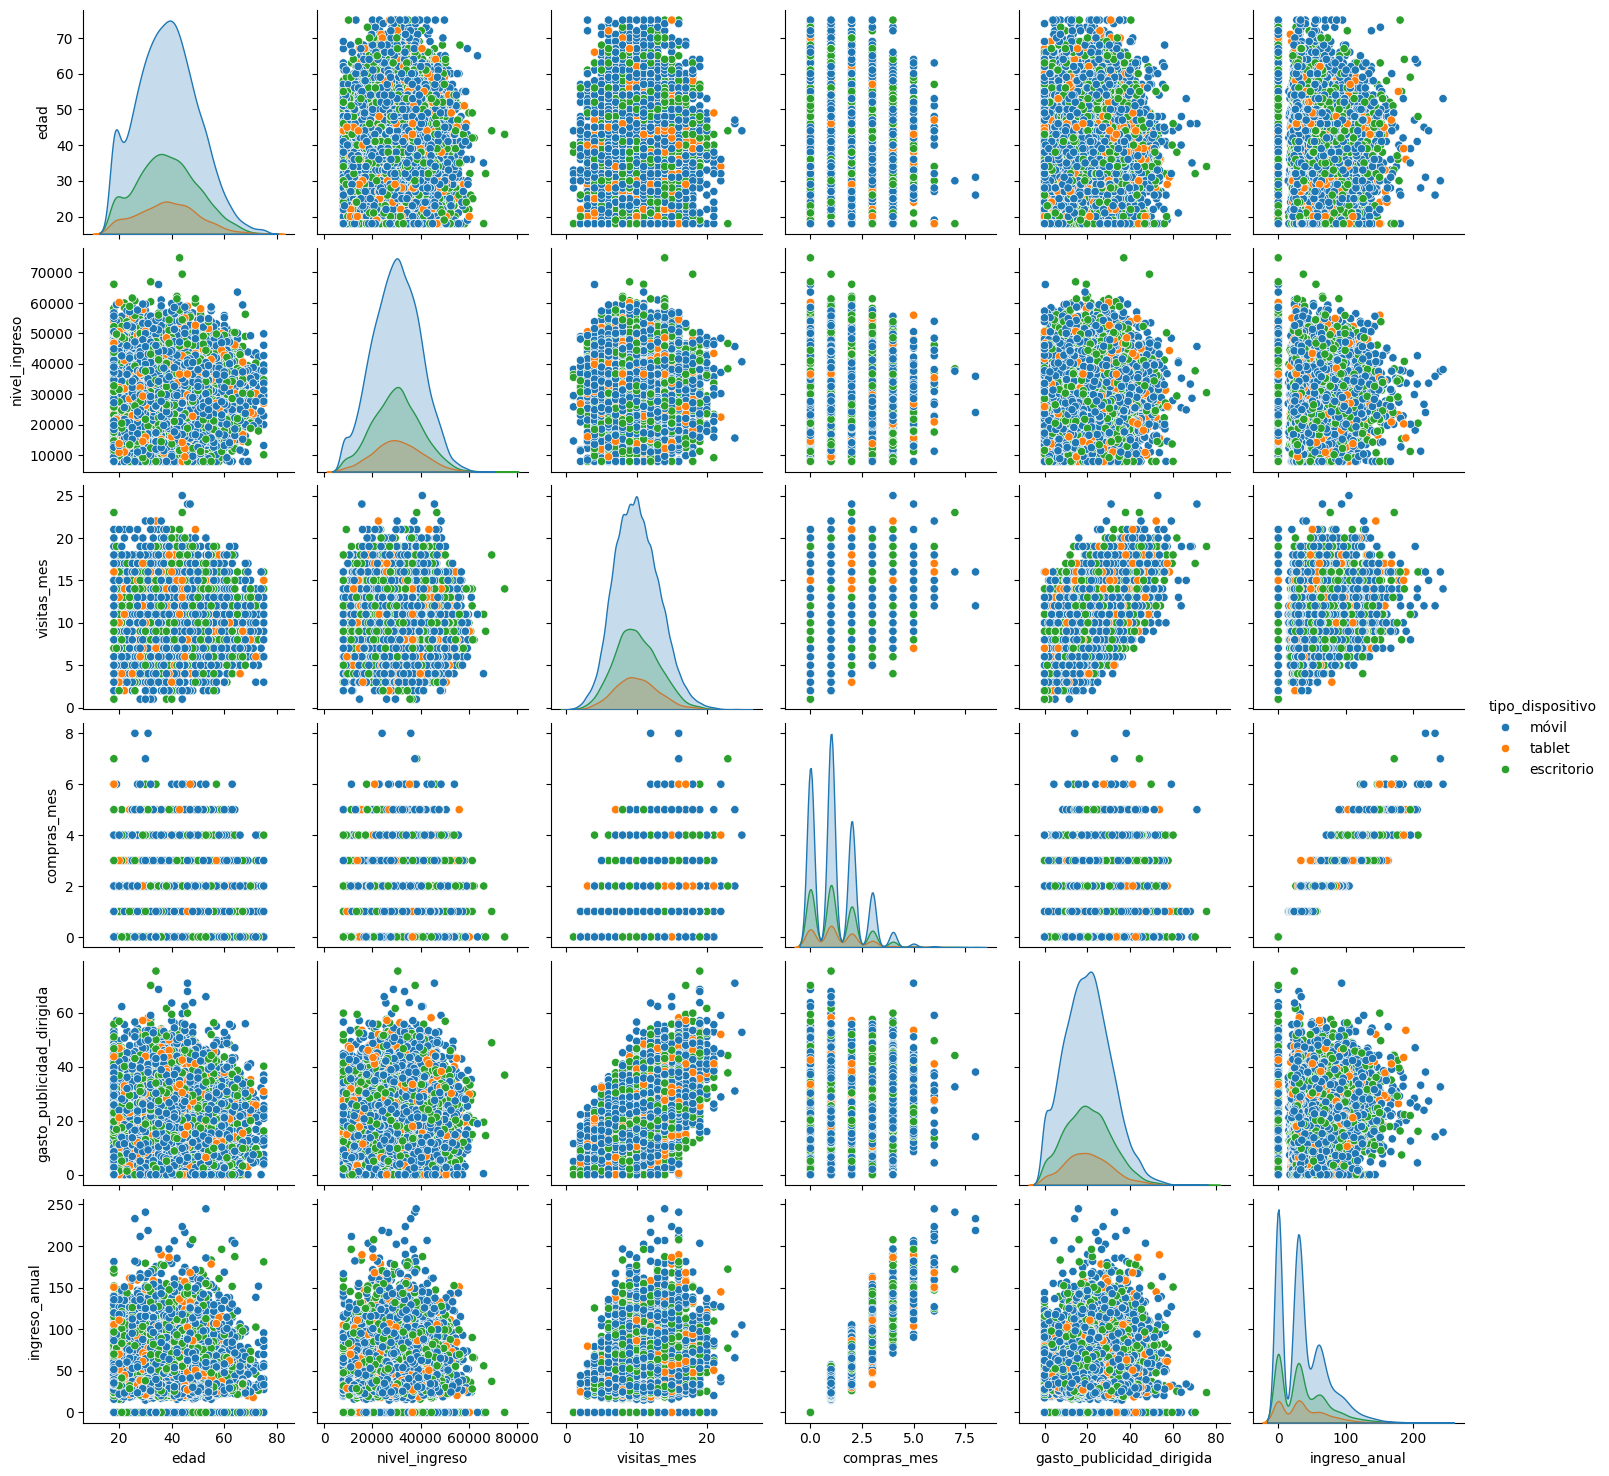

In [19]:
#Scatterplot general
sns.pairplot(df, hue="tipo_dispositivo")

### Scatterplot para pares clave

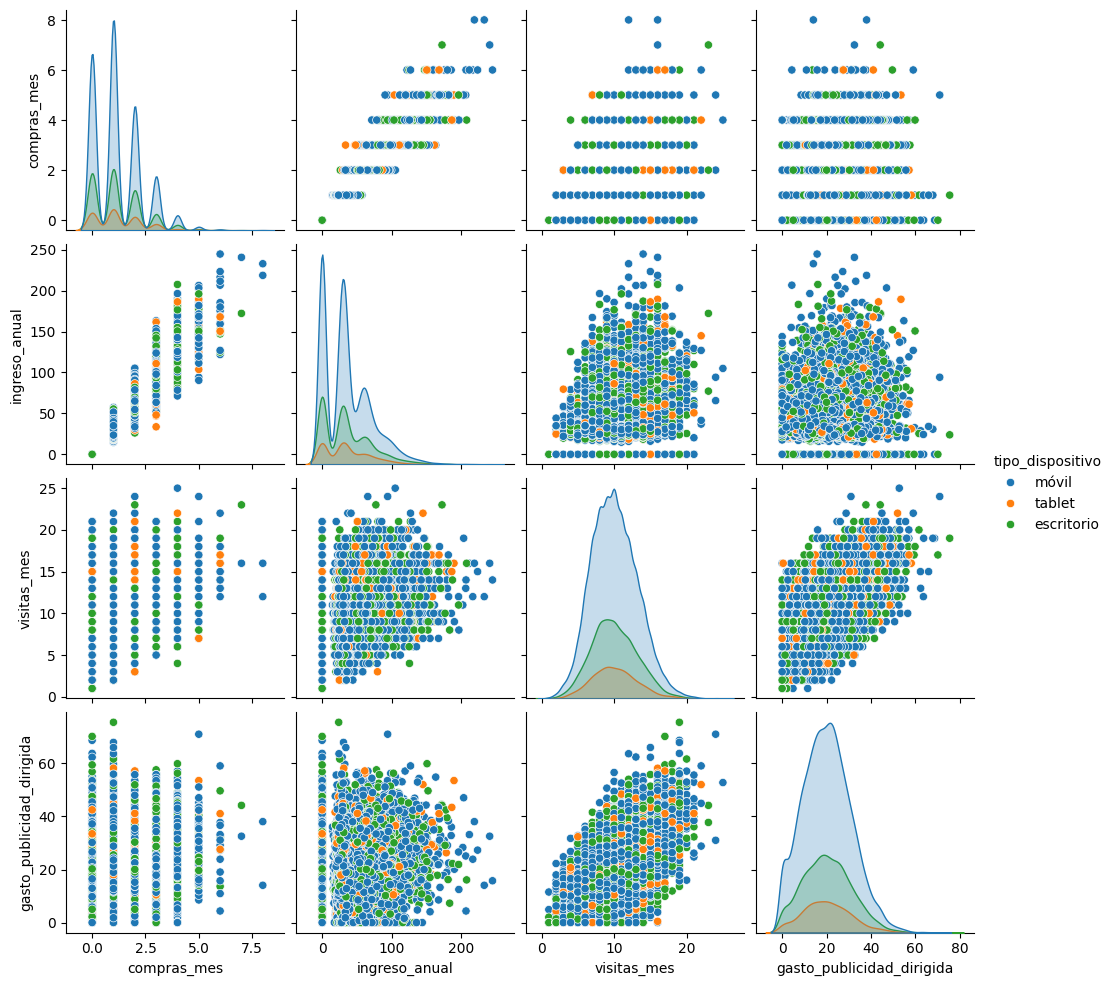

In [20]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.pairplot(df[['compras_mes', 'ingreso_anual','visitas_mes', 'gasto_publicidad_dirigida', 'tipo_dispositivo']], hue="tipo_dispositivo")

**compras_mes vs ingreso_anual**

- Dirección: positiva
- Dispersión: baja a media
- Outliers: algunos valores altos de ingreso anual
- Posible colinealidad: alta

Observaciones:

- Se observa una tendencia clara ascendente: a medida que aumentan las compras mensuales, el ingreso anual también aumenta.
- Los puntos están relativamente concentrados en una banda diagonal, lo que indica una relación fuerte entre ambas variables.
- Existen algunos clientes con ingresos anuales muy altos, que podrían considerarse clientes de alto valor.
- Esta relación coincide con la correlación observada en el heatmap (~0.97).

**visitas_mes vs gasto_publicidad_dirigida**

- Dirección: positiva
- Dispersión: media
- Outliers: pocos
- Posible colinealidad: moderada

Observaciones:

- Se aprecia una tendencia ascendente moderada, donde los usuarios con mayor gasto en publicidad dirigida tienden a tener más visitas a la plataforma.
- La dispersión es mayor que en el caso anterior, lo que indica que la relación existe pero no es tan fuerte.
- No se observan outliers extremos. Algunos puntos pueden mostrar alta inversión publicitaria con pocas visitas, o viceversa.
- Esto coincide con la correlación observada (~0.58).
- Esto sugiere que la publicidad podría estar asociada con mayor engagement del usuario.

**visitas_mes vs compras_mes**

- Dirección: positiva
- Dispersión: media
- Outliers: pocos
- Posible colinealidad: moderada

Observaciones:

- Los usuarios que visitan más la plataforma tienden a realizar más compras.
- La nube de puntos muestra una tendencia ascendente pero con dispersión considerable.
- Esto indica que visitar más la plataforma no siempre se traduce directamente en compras.
- La correlación observada (~0.35) confirma una relación moderada.

**visitas_mes vs ingreso_anual**

- Dirección: positiva
- Dispersión: media
- Outliers: algunos valores altos
- Posible colinealidad: baja a moderada

Observaciones:

- Se observa una ligera tendencia positiva, donde los usuarios con más visitas mensuales tienden a generar mayor ingreso anual.
- Sin embargo, la dispersión es relativamente amplia.
- Esto indica que la frecuencia de visita por sí sola no explica completamente el ingreso generado.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [21]:
# Calcular correlación entre variables relevantes (Pearson)
cols = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
def corr_numerica(df, columnas, metodo="pearson"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")
corr_matriz= corr_numerica(df, cols)
corr_matriz


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,0.197483
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,1.000000


In [22]:
# Calcular correlación entre variables relevantes (Spearman)
def corr_numerica(df, columnas, metodo="spearman"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")
corr_matriz= corr_numerica(df, cols)
corr_matriz

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
edad,1.000000,-0.007775,0.005205,0.015630,0.002869,0.016097
nivel_ingreso,-0.007775,1.000000,0.001420,0.009004,0.015393,0.025017
visitas_mes,0.005205,0.001420,1.000000,0.332943,0.559267,0.320954
compras_mes,0.015630,0.009004,0.332943,1.000000,0.192511,0.967482
gasto_publicidad_dirigida,0.002869,0.015393,0.559267,0.192511,1.000000,0.184999
ingreso_anual,0.016097,0.025017,0.320954,0.967482,0.184999,1.000000


**compras_mes vs ingreso_anual**

Correlación:

- Pearson: 0.97
- Spearman: 0.97

- Dirección: positiva
- Magnitud: muy fuerte
- Posible colinealidad: alta

Observaciones:

Existe una relación lineal extremadamente fuerte entre ambas variables.

A medida que aumenta el número de compras mensuales, también aumenta significativamente el ingreso anual generado por el cliente.

Los valores casi idénticos entre Pearson y Spearman indican que la relación es tanto lineal como monotónica.

Esto sugiere una posible colinealidad fuerte, lo cual es esperable dado que el ingreso anual depende directamente del volumen de compras.

**visitas_mes vs gasto_publicidad_dirigida**

Correlación:

- Pearson: 0.58
- Spearman: 0.56

- Dirección: positiva
- Magnitud: moderada a relativamente fuerte
- Posible colinealidad: moderada

Observaciones:

Se observa una relación positiva moderada, donde mayores niveles de gasto en publicidad dirigida están asociados con un mayor número de visitas mensuales.

La pequeña diferencia entre Pearson y Spearman sugiere que la relación es principalmente monotónica, aunque no perfectamente lineal.

Esto podría indicar que las campañas de marketing contribuyen a aumentar el engagement del usuario en la plataforma.

**visitas_mes vs compras_mes**

Correlación:

- Pearson: 0.35
- Spearman: 0.33

- Dirección: positiva
- Magnitud: moderada
- Posible colinealidad: baja a moderada

Observaciones:

Existe una relación positiva moderada, donde los usuarios que visitan la plataforma con mayor frecuencia tienden a realizar más compras.

Sin embargo, la relación no es particularmente fuerte, lo que indica que no todas las visitas se convierten en compras.

Esto sugiere oportunidades de mejora en estrategias de conversión dentro de la plataforma.

**visitas_mes vs ingreso_anual**

Correlación:

- Pearson: 0.34
- Spearman: 0.32

- Dirección: positiva
- Magnitud: moderada
- Posible colinealidad: baja

Observaciones:

Existe una relación positiva moderada entre la frecuencia de visitas y el ingreso generado por cliente.

Aunque los usuarios más activos tienden a generar más ingresos, la relación es considerablemente más débil que la observada con la frecuencia de compra.

Esto indica que visitar la plataforma no necesariamente implica generar ingresos, a menos que dichas visitas se conviertan en compras.

**gasto_publicidad_dirigida vs ingreso_anual**

Correlación:

- Pearson: 0.20
- Spearman: 0.18

- Dirección: positiva
- Magnitud: débil
- Posible colinealidad: baja

Observaciones:

Se observa una relación positiva débil, lo que sugiere que el gasto en publicidad dirigida tiene cierta asociación con el ingreso anual, pero su efecto es limitado.

Esto podría indicar que la publicidad influye indirectamente en el ingreso, posiblemente aumentando primero el número de visitas o interacciones.

## Variables con correlación prácticamente nula

Las siguientes variables muestran correlaciones cercanas a cero con la mayoría de las variables analizadas:

- edad
- nivel_ingreso

Observaciones:

No se observa una relación significativa entre estas variables demográficas y el ingreso anual generado.

Esto sugiere que el comportamiento del usuario dentro de la plataforma es más relevante que las características demográficas para explicar el ingreso generado.

### Punto-biserial

In [23]:
# Calcular correlación entre variables relevantes (miembro_premium)
from scipy.stats import pointbiserialr
cols_b = ['visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
for col in cols_b:
    coef, p_value = pointbiserialr(df["miembro_premium"],df[col])
    print(f"\nCorrelacion entre: miembro_premium y {col}")
    print(f"Point-Biserial: {coef:.4f}")
def corr_point_biserial(df, col_binaria, cols_b):

        for col in cols_b:
            coef, p_value = pointbiserialr(df[col_binaria],df[col])

            print(f"\nCorrelacion entre: {col_binaria} y {col}")
            print(f"Point-Biserial: {coef:.4f}")
corr_point_biserial( df, "miembro_premium", cols_b)



Correlacion entre: miembro_premium y visitas_mes
Point-Biserial: -0.0127

Correlacion entre: miembro_premium y compras_mes
Point-Biserial: 0.0034

Correlacion entre: miembro_premium y gasto_publicidad_dirigida
Point-Biserial: 0.0027

Correlacion entre: miembro_premium y ingreso_anual
Point-Biserial: 0.0931

Correlacion entre: miembro_premium y visitas_mes
Point-Biserial: -0.0127

Correlacion entre: miembro_premium y compras_mes
Point-Biserial: 0.0034

Correlacion entre: miembro_premium y gasto_publicidad_dirigida
Point-Biserial: 0.0027

Correlacion entre: miembro_premium y ingreso_anual
Point-Biserial: 0.0931


In [24]:
# Calcular correlación entre variables relevantes (abandono)
from scipy.stats import pointbiserialr
for col in cols_b:
    coef, p_value = pointbiserialr(df["abandono"],df[col])
    print(f"\nCorrelacion entre: abandono y {col}")
    print(f"Point-Biserial: {coef:.4f}")
def corr_point_biserial(df, col_binaria, cols_b):

        for col in cols_b:
            coef, p_value = pointbiserialr(df[col_binaria],df[col])

            print(f"\nCorrelacion entre: {col_binaria} y {col}")
            print(f"Point-Biserial: {coef:.4f}")
corr_point_biserial( df, "abandono", cols_b)



Correlacion entre: abandono y visitas_mes
Point-Biserial: -0.0089

Correlacion entre: abandono y compras_mes
Point-Biserial: 0.0083

Correlacion entre: abandono y gasto_publicidad_dirigida
Point-Biserial: -0.0046

Correlacion entre: abandono y ingreso_anual
Point-Biserial: -0.0028

Correlacion entre: abandono y visitas_mes
Point-Biserial: -0.0089

Correlacion entre: abandono y compras_mes
Point-Biserial: 0.0083

Correlacion entre: abandono y gasto_publicidad_dirigida
Point-Biserial: -0.0046

Correlacion entre: abandono y ingreso_anual
Point-Biserial: -0.0028


**Observaciones Punto-biserial:**


Los resultados muestran que las variables binarias del dataset presentan correlaciones muy débiles con las variables numéricas analizadas.

En particular:

miembro_premium muestra una ligera relación positiva con el ingreso anual, aunque su magnitud es baja. El coeficiente fue 0.0931.

abandono no presenta una relación significativa con las variables de comportamiento analizadas.

Esto sugiere que, dentro de este dataset, las variables de comportamiento (visitas y compras) explican mejor el ingreso anual que las variables binarias de segmentación de clientes.

### V de Cramér

In [25]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
col1 = "region"
col2 = "tipo_dispositivo"
col3 = "miembro_premium"
col4 = "abandono"

def cramer_v(df, col_1, col_2):
    # paso 1: tabla de contingencia
    tabla = pd.crosstab(df[col_1], df[col_2])

    # paso 2: calcular chi-cuadrado
    chi2, _, _, _ = chi2_contingency(tabla)

    # paso 3: calcular coeficiente V de Cramér
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    #mostrar resultado
    print(f"V de Cramér entre {col_1} vs {col_2}:", coef_v)

In [26]:
# Aplicar V de Cramér en variables relevantes

cramer_v(df, col1, col2)
cramer_v(df, col1, col3)
cramer_v(df, col2, col3)
cramer_v(df, col1, col4)

V de Cramér entre region vs tipo_dispositivo: 0.012378338407739397
V de Cramér entre region vs miembro_premium: 0.012574183027958334
V de Cramér entre tipo_dispositivo vs miembro_premium: 0.01972543445542166
V de Cramér entre region vs abandono: 0.015429712175030079


Observaciones V de Cramér
### region vs tipo_dispositivo

- V de Cramér: 0.012
#### Observaciones:
- La magnitud es extremadamente baja.
- Esto indica que la región del cliente no está asociada con el tipo de dispositivo utilizado para acceder a la plataforma.
- Los usuarios parecen utilizar dispositivos similares independientemente de la región.

### region vs miembro_premium

- V de Cramér: 0.013

#### Observaciones:

- La asociación es prácticamente inexistente.

- Esto sugiere que la probabilidad de ser miembro premium no depende de la región del usuario.

### tipo_dispositivo vs miembro_premium

- V de Cramér: 0.020

#### Observaciones:

- La relación sigue siendo muy débil.

- El tipo de dispositivo utilizado no parece influir en la probabilidad de que un usuario sea miembro premium.

### region vs abandono

- V de Cramér: 0.015

#### Observaciones:

- La asociación es prácticamente nula.

- El abandono de clientes no parece estar relacionado con la región geográfica.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio
---

### Hallazgo 1 - La frecuencia de compra es el factor más asociado al ingreso anual

**1. Evidencia visual**

Scatterplot entre compras_mes vs ingreso_anual, donde se observa una clara tendencia ascendente.

**2. Evidencia numérica**

Correlación:
- Pearson: 0.97
- Spearman: 0.97

Esto representa una correlación positiva extremadamente fuerte.

**3. Interpretación (no causal)**

Los clientes que realizan más compras al mes tienden a generar mayor ingreso anual para la plataforma.

Esto sugiere que la frecuencia de compra está fuertemente asociada con el valor económico del cliente.

**4. No podemos afirmar**

No podemos afirmar que incrementar directamente el número de compras causará automáticamente un aumento en el ingreso anual, ya que podrían existir otros factores involucrados (precio promedio, promociones, tipo de producto, etc.).

**5. Implicación de negocio**

Las estrategias de crecimiento podrían enfocarse en incrementar la frecuencia de compra, por ejemplo mediante:

- programas de recompensas
- recomendaciones personalizadas
- promociones para compras recurrentes

Esto podría ayudar a incrementar el valor del cliente a lo largo del tiempo.


### Hallazgo 2 - Más visitas a la plataforma están asociadas con mayor ingreso, pero la relación es moderada
**1 Evidencia visual**

Scatterplot entre visitas_mes vs ingreso_anual, donde se observa una tendencia positiva con dispersión moderada.

**2. Evidencia numérica**

Correlación:

- Pearson: 0.34

- Spearman: 0.32

Esto indica una correlación positiva moderada.

**3. Interpretación (no causal)**

Los usuarios que visitan la plataforma con mayor frecuencia tienden a generar más ingresos, aunque la relación no es tan fuerte como la frecuencia de compra.

Esto sugiere que la actividad en la plataforma puede contribuir al ingreso generado.

**4. No podemos afirmar**

No podemos afirmar que aumentar el número de visitas automáticamente incrementará el ingreso, ya que muchas visitas no necesariamente se convierten en compras.

**5. Implicación de negocio**

Podría ser útil mejorar la conversión de visitas a compras, por ejemplo mediante:

- optimización del proceso de compra

- recomendaciones de productos

- ofertas personalizadas

### Hallazgo 3 - El gasto en publicidad dirigida está asociado con mayor actividad del usuario
**1. Evidencia visual**

Scatterplot entre gasto_publicidad_dirigida vs visitas_mes, donde se observa una tendencia positiva.

**2. Evidencia numérica**

Correlación:

- Pearson: 0.58

- Spearman: 0.56

Esto indica una correlación positiva moderada.

**3. Interpretación (no causal)**

Los clientes que reciben mayor inversión en publicidad dirigida tienden a visitar la plataforma con mayor frecuencia.

Esto sugiere que las campañas de marketing podrían estar asociadas con mayor engagement del usuario.

**4. No podemos afirmar**

No podemos afirmar que la publicidad sea la causa directa del aumento en las visitas, ya que podría existir segmentación previa hacia usuarios ya activos.

**5. Implicación de negocio**

Las estrategias de marketing podrían enfocarse en optimizar la segmentación de campañas, con el objetivo de aumentar la interacción de los usuarios con la plataforma.

## Hallazgo 4: Variables demográficas y categóricas tienen poca asociación con el ingreso

** 1. Evidencia numérica**

Correlaciones cercanas a 0:

- edad vs ingreso_anual → 0.017

- nivel_ingreso vs ingreso_anual → 0.017

Cramér's V:

- region vs abandono → 0.015

- region vs miembro_premium → 0.012

**2. Interpretación (no causal)**

Las características demográficas o geográficas no parecen estar fuertemente asociadas con el ingreso generado por los clientes.

**3. No podemos afirmar**

No podemos afirmar que estas variables no tengan ningún impacto, ya que podrían influir de forma indirecta o en otros contextos no capturados en el dataset.

**4. Implicación de negocio**

Las estrategias de crecimiento podrían centrarse más en el comportamiento del usuario dentro de la plataforma (visitas, compras, engagement) que en características demográficas.

## Sección 6 - Limitaciones y próximos pasos


### **Limitaciones**
- Correlación ≠ causalidad

Este análisis se basa principalmente en métodos correlacionales (Pearson, Spearman, punto-biserial y V de Cramér).

Por lo tanto, no es posible afirmar relaciones causales entre las variables analizadas. Las asociaciones identificadas únicamente indican que dos variables tienden a variar juntas, pero no permiten determinar si una variable provoca cambios en la otra.

### **Próximos pasos**
Probar segmentación adicional

Una posible extensión del análisis sería explorar segmentaciones más detalladas de los usuarios para identificar patrones de comportamiento específicos.

Opción 1

Segmentar clientes según niveles de actividad, por ejemplo:

- usuarios con pocas visitas

- usuarios moderadamente activos

- usuarios altamente activos

Esto permitiría analizar si las relaciones entre variables cambian según el nivel de engagement del cliente.

Opción 2

Segmentar usuarios según nivel de ingreso anual generado, por ejemplo:

- clientes de bajo valor

- clientes de valor medio

- clientes de alto valor

Esto podría ayudar a identificar qué comportamientos caracterizan a los clientes más valiosos para la plataforma.

Paso 2: Análisis predictivo

Opción 1

Construir un modelo de regresión para estimar el ingreso anual generado por un cliente a partir de variables de comportamiento como:

- visitas mensuales

- compras mensuales

- gasto en publicidad dirigida

Esto permitiría evaluar qué variables contribuyen más a predecir el ingreso anual.

Paso 3: Análisis de retención de clientes

Opción 1

Explorar con mayor detalle los factores asociados al abandono de clientes (churn), por ejemplo mediante:

- comparación entre clientes activos vs abandonados

- análisis de comportamiento previo al abandono

- identificación de señales tempranas de churn

Esto podría ayudar al negocio a desarrollar estrategias de retención más efectivas.
Probar segmentación adicional